# Третья лабораторная работа
## Основы PyTorch и обучение полносвязной нейронной сети
## Цель задания
В этой лабораторной работе необходимо пройти все этапы создания и обучения
нейронной сети на Python с использованием библиотеки PyTorch. Цель — научиться работать с тензорами, понять принцип автоматического
вычисления градиентов и создать простую полносвязную нейронную сеть
для классификации табличных данных.

In [2]:
import torch
import os, shutil
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import pandas as pd
import torchvision.models as models

## 2. Предобработка данных


In [3]:
os.makedirs("./data/splits/test/dummy", exist_ok=True)

for f in os.listdir("./data/splits/test"):
    if f.endswith(".png"):
        shutil.move(
            os.path.join("./data/splits/test", f),
            os.path.join("./data/splits/test/dummy", f)
        )

In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder("./data/splits/train", transform=train_transform)
val_ds   = datasets.ImageFolder("./data/splits/val", transform=test_transform)
test_ds  = datasets.ImageFolder("./data/splits/test", transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([64, 3, 128, 128])


## 2. Построение и обучение свёрточной модели

In [5]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
model.to(device)

# первый conv слой
first_conv = model.features[0][0]

filters = first_conv.weight.detach().cpu()

print(filters.shape)
crit = nn.CrossEntropyLoss()
opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)


torch.Size([32, 3, 3, 3])


### 2.1 Обучение


In [29]:
print(torch.backends.mps.is_available())

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


PATIENCE = 5

best_val = -1.0
best_epoch = 0
train_losses = []
val_accs = []

epoch = 1
while True:
    model.train()
    running_loss = 0.0
    n = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        opt.zero_grad()
        out = model(imgs)
        loss = crit(out, labels)
        loss.backward()
        opt.step()
        running_loss += loss.item() * imgs.size(0)
        n += imgs.size(0)
    train_loss = running_loss / n
    train_losses.append(train_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            preds = out.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d}  train_loss={train_loss:.4f}  val_acc={val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        best_epoch = epoch
        torch.save(model.state_dict(), "best_model.pth")
        print("  -> saved best_model.pth")

    if epoch - best_epoch >= PATIENCE:
        print(f"Early stopping (no improvement for {PATIENCE} epochs).")
        break

    epoch += 1

True
Epoch 01  train_loss=0.9038  val_acc=0.8616
  -> saved best_model.pth
Epoch 02  train_loss=0.7196  val_acc=0.8800
  -> saved best_model.pth
Epoch 03  train_loss=0.6650  val_acc=0.8792
Epoch 04  train_loss=0.6285  val_acc=0.9000
  -> saved best_model.pth
Epoch 05  train_loss=0.6056  val_acc=0.8952
Epoch 06  train_loss=0.5816  val_acc=0.9060
  -> saved best_model.pth
Epoch 07  train_loss=0.5607  val_acc=0.9056
Epoch 08  train_loss=0.5534  val_acc=0.9036
Epoch 09  train_loss=0.5307  val_acc=0.9038
Epoch 10  train_loss=0.5243  val_acc=0.9006
Epoch 11  train_loss=0.5105  val_acc=0.9136
  -> saved best_model.pth
Epoch 12  train_loss=0.4947  val_acc=0.9128
Epoch 13  train_loss=0.4827  val_acc=0.9168
  -> saved best_model.pth
Epoch 14  train_loss=0.4824  val_acc=0.9198
  -> saved best_model.pth
Epoch 15  train_loss=0.4768  val_acc=0.9140
Epoch 16  train_loss=0.4696  val_acc=0.9152


KeyboardInterrupt: 

### 2.2 Тест

Saved submission.csv with 300000 rows


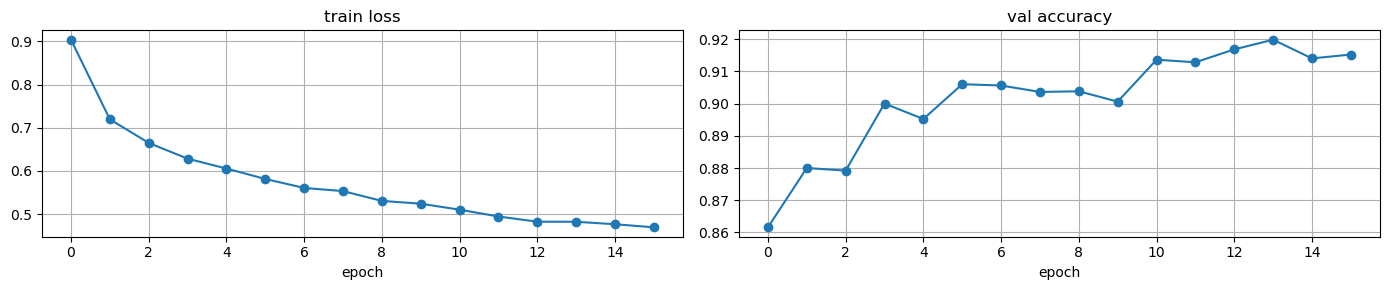

In [30]:
model.eval()
model.to(device)

names_all = [os.path.basename(p) for p, _ in test_ds.samples]

preds = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        batch_preds = out.argmax(dim=1).cpu().tolist()
        preds.extend(batch_preds)

CIFAR10_CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
labels_names = [CIFAR10_CLASS_NAMES[p] for p in preds]

ids = [int(Path(n).stem) for n in names_all]
df = pd.DataFrame({"id": ids, "label": labels_names})

df = df.sort_values("id").reset_index(drop=True)
df.to_csv("submission.csv", index=False)

print("Saved submission.csv with", len(df), "rows")

plt.figure(figsize=(14, 3))
plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.title("train loss")
plt.xlabel("epoch")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(val_accs, marker='o')
plt.title("val accuracy")
plt.xlabel("epoch")
plt.grid(True)
plt.tight_layout()
plt.savefig("curves.png", dpi=150)
plt.show()

## 3. Анализ

### 3.1 Нормализация

In [2]:
filters = (filters - filters.min()) / (filters.max() - filters.min())

NameError: name 'filters' is not defined

### 3.2 Визуализация


In [1]:
n_filters = filters.shape[0]

fig, axes = plt.subplots(4, 8, figsize=(12,6))

for i, ax in enumerate(axes.flat):
    if i < n_filters:
        f = filters[i]

        # преобразуем из [3, H, W] -> [H, W, 3]
        f = f.permute(1,2,0)

        ax.imshow(f)
        ax.axis('off')

plt.tight_layout()
plt.show()

NameError: name 'filters' is not defined